In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px 

from sklearn.preprocessing import StandardScaler

from non_parametric_pro.density import ProParameters, pro_logdensity_fn
from non_parametric_pro.sgld import parametric_sgld, sgld
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro, run_inference_algorithm_with_burn_in
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.inducing import PointInducingBasis, compute_inducing_basis, kmeans_inducing_points, RFFInducingBasis, sample_rff_frequencies
from non_parametric_pro.parameter_adaptation import cross_validated_parameter_adaptation
from non_parametric_pro.gp import natural_gradient_svgp_fit

jax.config.update("jax_enable_x64", True)

In [2]:
dataset_name = "whitewine"
split = 1

num_inducing_points = 200

In [ ]:
key = jr.PRNGKey(0)

example = load_uci_regression_dataset(dataset_name, split=split)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train = jnp.array(scaler_x.fit_transform(example.x_train))
y_train = jnp.array(scaler_y.fit_transform(example.y_train))

x_test = scaler_x.transform(example.x_test)
y_test = scaler_y.transform(example.y_test)

In [4]:
D = x_train.shape[1]
N = x_train.shape[0]

data = gpx.Dataset(X=x_train, y=y_train)
lengthscale = gpx.parameters.SigmoidBounded(
    jnp.sqrt(D) * jnp.ones((D,)), low=1e-3, high=1e3
)
kernel = gpx.kernels.RBF(lengthscale=lengthscale, variance=px.NonTrainable(jnp.array(1.0)))
prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n, obs_stddev=jnp.sqrt(0.01))
posterior = prior * likelihood

key, km_key = jr.split(key)

z_init = kmeans_inducing_points(km_key, x_train, num_inducing_points).z 

variational_family = gpx.variational_families.CollapsedVariationalGaussian(
    posterior=posterior,
    inducing_inputs=z_init,
)

opt_variational_family, _ = gpx.fit_scipy(
    model=variational_family,
    objective=lambda p, d: -gpx.objectives.collapsed_elbo(p, d),
    train_data=data,
    verbose=False,
)

vgp_posterior = opt_variational_family.posterior

In [5]:
vgp_latent_dist = opt_variational_family.predict(x_test, train_data=data)
vgp_predictive_dist = vgp_posterior.likelihood(vgp_latent_dist)

vgp_predictive_mean = vgp_predictive_dist.mean
vgp_predictive_std = jnp.sqrt(vgp_predictive_dist.variance)

vgp_sigma = vgp_posterior.likelihood.obs_stddev
vgp_kernel = vgp_posterior.prior.kernel

z_opt = px.unwrap(opt_variational_family.inducing_inputs)

print("VGP sigma:", px.unwrap(vgp_sigma))
print("VGP NLPD:", nlpd_gp(y_test, vgp_predictive_mean, vgp_predictive_std))

VGP sigma: 0.833127661703827
VGP NLPD: 1.2582262678585923


In [55]:
px.unwrap(vgp_kernel.lengthscale)

Array([1.00000000e+03, 1.00000000e+03, 1.00000000e+03, 3.75079891e-01,
       1.00000000e+03, 1.73436209e+00, 8.08577902e+00, 1.47769918e+00,
       9.99981123e+02, 1.00000000e+03, 9.87368782e+02], dtype=float64)

In [ ]:
sigma_min = 0.1

pro_kernel = vgp_kernel
pro_sigma = gpx.parameters.SigmoidBounded(0.2, low=sigma_min, high=100.0)

J = 32
num_steps = 30000
batch_size = 1000

inducing_basis = PointInducingBasis(z=z_opt)
initial_position = jr.normal(key, (inducing_basis.output_dim(), J))

pro_params = ProParameters(
    y=y_train,
    step_size=1e-4,
    sigma=pro_sigma,
    alpha=0.6,
)

basis, residual_std = compute_inducing_basis(inducing_basis, pro_kernel, x_train, jitter=1e-6)
pro_params = pro_params._replace(basis=basis, residual_std=residual_std)

sgld_algo = sgld(batch_size=batch_size)

<div><progress max="27000" value="27000"></progress> 100.00% [27000/27000 00:00&lt;?]</div>

<div><progress max="3000" value="3000"></progress> 100.00% [3000/3000 00:00&lt;?]</div>

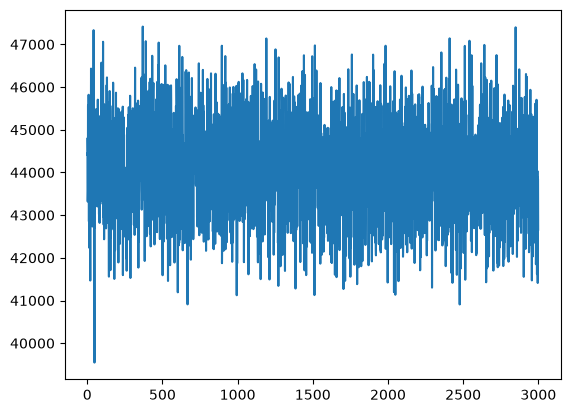

In [77]:
algorithm = parametric_sgld(pro_logdensity_fn, pro_params, batch_size=batch_size)
initial_position = jr.normal(key, (inducing_basis.output_dim(), J))

_, (states, info) = run_inference_algorithm_with_burn_in(
    rng_key=key,
    inference_algorithm=algorithm,
    num_steps=30000,
    burn_ratio=0.9,
    initial_position=initial_position,
    progress_bar=True
)

plt.plot(-info.score)
plt.show()

In [ ]:
# adaptation = cross_validated_parameter_adaptation(
#     sgld_algo,
#     pro_logdensity_fn,
#     pro_params,
#     x_full=x_train,
#     y_full=y_train,
#     initial_kernel=pro_kernel,
#     num_folds=1,
#     val_fraction=0.2,
#     num_particles=J,
#     num_steps=10000,
#     warmup_steps=1000,
#     sigma_adapt_steps=100,
#     kernel_adapt_steps=0,
#     objective_fn=pro_logdensity_fn,
#     sigma_optimizer=ox.adam(1e-1),
#     kernel_optimizer=ox.adam(1e-2),
#     adapt_target=None,
#     progress_bar=True,
#     rng_key=key,
#     inducing_basis=inducing_basis,
# )

# adapt_params = pro_params._replace(sigma=adaptation.sigma)
# adapt_kernel = adaptation.kernel
# basis, residual_std = compute_inducing_basis(inducing_basis, adapt_kernel, x_train, jitter=1e-6)
# adapt_params = adapt_params._replace(basis=basis, residual_std=residual_std)

Running parameter adaptation


<div><progress max="10000" value="10000"></progress> 100.00% [10000/10000 00:00&lt;?]</div>

In [80]:
particles = states.position[::50]

test_basis, test_cov = prediction_basis(pro_kernel, x_train, x_train, pro_params, inducing_basis=inducing_basis)

vgp_latent_dist = vgp_posterior.predict(x_train, train_data=data)
vgp_predictive_dist = vgp_posterior.likelihood(vgp_latent_dist)

vgp_predictive_mean = vgp_predictive_dist.mean
vgp_predictive_std = jnp.sqrt(vgp_predictive_dist.variance)

print("PRO NLPD:", nlpd_pro(y_train, test_basis, test_cov, particles, parameters=pro_params))
print("VGP NLPD:", nlpd_gp(y_train, vgp_predictive_mean, vgp_predictive_std))

PRO NLPD: 0.7024728693604186
VGP NLPD: 1.2237459189592361


In [81]:
test_basis, test_cov = prediction_basis(pro_kernel, x_train, x_test, pro_params, inducing_basis=inducing_basis)

vgp_latent_dist = vgp_posterior.predict(x_test, train_data=data)
vgp_predictive_dist = vgp_posterior.likelihood(vgp_latent_dist)

vgp_predictive_mean = vgp_predictive_dist.mean
vgp_predictive_std = jnp.sqrt(vgp_predictive_dist.variance)

print("PRO NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params))
print("VGP NLPD:", nlpd_gp(y_test, vgp_predictive_mean, vgp_predictive_std))

PRO NLPD: 0.9437045273913369
VGP NLPD: 1.257832330316795
